# We are going to be testing in the classic scenario

In [470]:
from utils.generating_data import gen_data
from utils.multiple_testing import p_function_static, e_function_static, eBH
from utils.subroutines import subroutine_familywise, subroutine
from utils.CC import CC_grid
from collections import defaultdict

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from utils.Adadetect import AdaDetectERM

import time
import pandas as pd
import numpy as np

In [472]:
def eBH_vector(e, alpha):  
    m = len(e)
    
    e_sort = np.sort(e)[::-1] # descending order
    khat = 0
    for k in range(m,0,-1):
        if e_sort[k-1] >= m/(alpha*k):
            khat = k
            break
    
    if khat == 0:
        threshold = np.inf
    else:
        threshold = m/(alpha*khat)
    return (e >= threshold)*1

def pBH_threshold(resampled_score_matrix, cal_weights, test_weights, U, alpha_fdr, j):
    m = len(test_weights)
    n = len(cal_weights)
    
    p_tilde = p_function_static(resampled_score_matrix, cal_weights, test_weights, U=U)
    p_rej_vector = eBH_vector(1/p_tilde, alpha_fdr)
    
    hatR = sum(p_rej_vector) + (1 - p_rej_vector[j])    # R U {j}
    
    return (m/alpha_fdr) * (p_tilde[j] / hatR)

def hatR_p_combination(resampled_score_matrix, cal_weights, test_weights, U, alpha_fdr, j, e_anchor=True):
    # this one uses pvalue strat until we get out of the p-value rejection set
    m = len(test_weights)
    n = len(cal_weights)
    
    if e_anchor:
        e_tilde = e_function_static(alpha_fdr, resampled_score_matrix, cal_weights, test_weights)
        e_rej_vector = eBH_vector(e_tilde, alpha_fdr)

        if e_rej_vector[j] == 1:
            # if j contained in original e-BH rejection set, then hatR set as the original e-BH rejecetion set size
            hatR = sum(e_rej_vector)
            
    return hatR

def CC_grid_double(resampled_scores_list, cal_weights, test_weights, alpha_fdr, randomness, CC_stat, R_stat, j):
    U_support = np.arange(1, randomness + 1) / randomness   
    indic_over_R_vector = np.zeros_like(U_support)
    for k, u in enumerate(U_support):
        c_u = p_value_j(real_score_matrix, cal_weights, test_weights, u, alpha_fdr, j)    # observed statistic when U=u
        hatR_u = hatR_pval_strata(real_score_matrix, cal_weights, test_weights, u, alpha_fdr, j) 
        cond_expectation, numerical_error = CC_grid(
            c_u, 
            resampled_scores_list, cal_weights, test_weights, alpha_BH, 
            randomness, p_value_j, hatR_pval_strata,
            j
        )    # this is technically the inner integral, evaluate it at the point c_u in the support of the random c_U
        indic_over_R_vector[k] = int(cond_expectation <= 0) / hatR_u

    outer_integral = np.mean(indic_over_R_vector)
    
    return outer_integral

def U_integrand(u_tilde, c, resampled_scores_list, cal_weights, test_weights, alpha_fdr, CC_stat, R_stat, j):
    m = len(test_weights)
    n = len(cal_weights)
    assert resampled_scores_list.shape == (n+1, m, n+m)
    
    probabilities = np.ones(n+1)
    probabilities[:n] = cal_weights
    probabilities[n] = test_weights[j]
    probabilities = probabilities / sum(probabilities)
    
    summation = 0
    for idx in range(n+1):
        resampled_score_matrix = resampled_scores_list[idx]
        
        # u_tilde represents the randomness
        resampled_stat = CC_stat(resampled_score_matrix, cal_weights, test_weights, u_tilde, alpha_fdr, j)
        resampled_hatR = R_stat(resampled_score_matrix, cal_weights, test_weights, u_tilde, alpha_fdr, j)
        e_tilde = e_function_static(alpha_fdr, resampled_score_matrix, cal_weights, test_weights)
        budget_j = 1 # e_function_idx_static(2 * alpha_fdr, resampled_score_matrix, cal_weights, test_weights, idx=j)

        e_rej_vector = eBH_vector(e_tilde, alpha_fdr)
        indic = int( (e_rej_vector[j] == 1) or (resampled_stat <= c) )
        
        summation += ((m/alpha_fdr * indic/resampled_hatR) - budget_j) * probabilities[idx]
     
    return summation  


def p_value_j(resampled_score_matrix, cal_weights, test_weights, U, alpha_fdr, j):
    return p_function_idx_static(resampled_score_matrix, cal_weights, test_weights, idx=j, U=U)
        
def pBH_threshold(resampled_score_matrix, cal_weights, test_weights, U, alpha_fdr, j):
    m = len(test_weights)
    n = len(cal_weights)
    
    p_tilde = p_function_static(resampled_score_matrix, cal_weights, test_weights, U=U)
    # R = max(1, sum(eBH_vector(1/p_tilde, alpha_fdr)))
    p_rej_vector = eBH_vector(1/p_tilde, alpha_fdr)
    
    hatR = sum(p_rej_vector) + (1 - p_rej_vector[j])    # R U {j}
    
    return (m/alpha_fdr) * (p_tilde[j] / hatR)   # returns m/a  * p_j(U)/R(U)


# hatR functions for CC
def hatR_pval_strata(resampled_score_matrix, cal_weights, test_weights, U, alpha_fdr, j, e_anchor=True):
    m = len(test_weights)
    n = len(cal_weights)    
    
    if e_anchor:
        e_tilde = e_function_static(alpha_fdr, resampled_score_matrix, cal_weights, test_weights)
        e_rej_vector = eBH_vector(e_tilde, alpha_fdr)
        
        if e_rej_vector[j] == 1:
            # if j contained in original e-BH rejection set, then hatR set as the original e-BH rejecetion set size
            hatR = sum(e_rej_vector)
            
#         if sum(e_rej_vector) > hatR:
#             hatR = sum(e_rej_vector)
            
            return hatR
        
    p_tilde = p_function_static(resampled_score_matrix, cal_weights, test_weights, U=U)

    p_tilde_unnormalized = ((p_tilde - U) * (n+1)).astype(np.int32) 
    hatR = sum(p_tilde_unnormalized <= p_tilde_unnormalized[j])   # count how many are tied or less than the jth p-value
    
    return hatR

def hatR_p_rej(resampled_score_matrix, cal_weights, test_weights, U, alpha_fdr, j):
    m = len(test_weights)
    n = len(cal_weights)
    
    p_tilde = p_function_static(resampled_score_matrix, cal_weights, test_weights, U=U)
    p_rej_vector = eBH_vector(1/p_tilde, alpha_fdr)
        
    hatR = sum(p_rej_vector) + (1 - p_rej_vector[j])
    return hatR


def hatR_p_combination(resampled_score_matrix, cal_weights, test_weights, U, alpha_fdr, j, e_anchor=True):
    # this one uses pvalue strat until we get out of the p-value rejection set
    m = len(test_weights)
    n = len(cal_weights)
    
    if e_anchor:
        e_tilde = e_function_static(alpha_fdr, resampled_score_matrix, cal_weights, test_weights)
        e_rej_vector = eBH_vector(e_tilde, alpha_fdr)

        if e_rej_vector[j] == 1:
            # if j contained in original e-BH rejection set, then hatR set as the original e-BH rejecetion set size
            hatR = sum(e_rej_vector)
            
            return hatR
    
    p_tilde = p_function_static(resampled_score_matrix, cal_weights, test_weights, U=U)

    # find the ranks
    p_tilde_unnormalized = ((p_tilde - U) * (n+1)).astype(np.int32) 
    n_tied_or_smaller = sum(p_tilde_unnormalized <= p_tilde_unnormalized[j])
    
    # find the p-value rejection set 
    p_rej_vector = eBH_vector(1/p_tilde, alpha_fdr)
    
    # if this is empty, just try to reject the smallest strata of p-values
    if sum(p_rej_vector) == 0:
        return n_tied_or_smaller

    if n_tied_or_smaller < sum(p_rej_vector):
        # we're within the strata of pBH
        # i.e., there are p-values bigger than p_j that have still be rejected by BH
        
        hatR = n_tied_or_smaller                
    else:
        # in this case, we're either in the stratum of the largest p-values still rejected by BH
        hatR = sum(p_rej_vector) + (1 - p_rej_vector[j])
                
    return hatR

def U_integrand(u_tilde, c, resampled_scores_list, cal_weights, test_weights, alpha_fdr, CC_stat, R_stat, j):
    m = len(test_weights)
    n = len(cal_weights)
    
    # print(resampled_scores_list.shape)
    # print((n+1, n, n+m))
    
    assert resampled_scores_list.shape == (n+1, m, n+m)
    
    probabilities = np.ones(n+1)
    probabilities[:n] = cal_weights
    probabilities[n] = test_weights[j]
    probabilities = probabilities / sum(probabilities)
    
    summation = 0
    for idx in range(n+1):
        resampled_score_matrix = resampled_scores_list[idx]
        
        # u_tilde represents the randomness
        resampled_stat = CC_stat(resampled_score_matrix, cal_weights, test_weights, u_tilde, alpha_fdr, j)
        resampled_hatR = R_stat(resampled_score_matrix, cal_weights, test_weights, u_tilde, alpha_fdr, j)
    
#         p_tilde = p_function_static(resampled_score_matrix, cal_weights, test_weights, U=u_tilde)
#         p_tilde_j = p_tilde[j] 
        e_tilde = e_function_static(alpha_fdr, resampled_score_matrix, cal_weights, test_weights)
        budget_j = 1 # e_function_idx_static(2 * alpha_fdr, resampled_score_matrix, cal_weights, test_weights, idx=j)

        e_rej_vector = eBH_vector(e_tilde, alpha_fdr)
        indic = int( (e_rej_vector[j] == 1) or (resampled_stat <= c) )
        
        summation += ((m/alpha_fdr * indic/resampled_hatR) - budget_j) * probabilities[idx]
     
    return summation  

# calculation of the CC conditional expectation
def CC_exact(c, resampled_scores_list, integrand, cal_weights, test_weights, alpha_fdr, j):
    # integrand is a (numba) function of resampled_score_matrix_dict[j] (and weights, fast_coefs[j], alpha_fdr)
    n = len(cal_weights)
    
    probabilities = np.ones(n+1)
    probabilities[:n] = cal_weights
    probabilities[n] = test_weights[j]
    probabilities = probabilities / sum(probabilities)
    
    expectation = 0
    
    for idx in range(n+1):
        # idx goes over {1, ..., n+1}
        term_inside_expectation = integrand(resampled_scores_list[idx], cal_weights, test_weights, alpha_fdr, c, j)
        # print(term_inside_expectation)
        # print()
        expectation += ( probabilities[idx] * term_inside_expectation )
    
#     print(expectation)
    
    return expectation   # if this is at most 0, then we boost


def CC_integral(c, resampled_scores_list, cal_weights, test_weights, alpha_fdr, j):
    cond_expectation, error = integrate.quad(
        U_integrand,  # function to integrate
        0, 1,  # integration limits for u_tilde
        args=(c, resampled_scores_list, cal_weights, test_weights, alpha_fdr, j)  # the other args
    )
    return cond_expectation, error

def CC_grid(c, resampled_scores_list, cal_weights, test_weights, alpha_fdr, randomness, CC_stat, R_stat, j):
    """
        evaluate the CC cond expectation at c
    """
    error = None   # in this case, no need for numerical methods, so no numerical error
    if randomness == 0:
        # in this case, we are not using randomized p-values
        # print('b4')
        cond_expectation = U_integrand(
            1, c, # u_tilde set to 1
            resampled_scores_list, cal_weights, test_weights, alpha_fdr, 
            CC_stat, R_stat,
            j
        )
        # print('af')
        return cond_expectation, error 
        
    
    U_support = np.arange(1, randomness + 1) / randomness
    
    grid_values = np.zeros(len(U_support))
    
    for idx in range(len(U_support)):
        u_tilde = U_support[idx]
        grid_values[idx] = U_integrand(
            u_tilde, c, 
            resampled_scores_list, cal_weights, test_weights, alpha_fdr, 
            CC_stat, R_stat,
            j
        )

    cond_expectation = np.mean(grid_values)
    return cond_expectation, error

def CC_grid_double(resampled_scores_list, cal_weights, test_weights, alpha_fdr, randomness, CC_stat, R_stat, j):
    U_support = np.arange(1, randomness + 1) / randomness   
    indic_over_R_vector = np.zeros_like(U_support)
    for k, u in enumerate(U_support):
        c_u = p_value_j(real_score_matrix, cal_weights, test_weights, u, alpha_fdr, j)    # observed statistic when U=u
        hatR_u = hatR_pval_strata(real_score_matrix, cal_weights, test_weights, u, alpha_fdr, j) 
        cond_expectation, numerical_error = CC_grid(
            c_u, 
            resampled_scores_list, cal_weights, test_weights, alpha_BH, 
            randomness, p_value_j, hatR_pval_strata,
            j
        )    # this is technically the inner integral, evaluate it at the point c_u in the support of the random c_U
        indic_over_R_vector[k] = int(cond_expectation <= 0) / hatR_u

    outer_integral = np.mean(indic_over_R_vector)
    
    return outer_integral


In [474]:
n = 500
m = 50
prop_outliers = 0.2
amp = 20
adjustment = 0.8
alpha_fdr = .4
K_blocks = 5

#We repeat the same structure of the experiement
Wset = np.random.uniform(size=(50,50)) * 6 - 3
n_outliers = int(np.ceil(m * prop_outliers))

# generate null and alternative hypotheses
perm = np.random.permutation(m) 
nonzero = np.sort(perm[:n_outliers])
nulls = np.sort(perm[n_outliers:])

# ---------------- UNWEIGHTED -----------------------

Xref = gen_data(Wset, n, 1)

# don't generate test dataset under covariate shift
Xtest0 = gen_data(Wset, m-n_outliers, 1)    # inliers 
Xtest1 = gen_data(Wset, n_outliers, amp)    # outliers

# weights are just ones vector
test_weights = np.ones(m)
cal_weights = np.ones(n)

Xtest = np.zeros((m, Xtest0.shape[1]))
Xtest[nonzero,] = Xtest1
Xtest[nulls,] = Xtest0

# ---------------------------------------------------
classifier = OneClassSVM(nu=0.004, kernel='rbf', gamma='scale')

In [476]:
blocks = np.array_split(np.arange(m), K_blocks)
baseline_score_matrix = subroutine(classifier, Xref, Xtest, blocks) 

test_weights = np.ones(m)
cal_weights = np.ones(n)

e_values_KFC = e_function_static(adjustment*alpha_fdr, baseline_score_matrix, cal_weights, test_weights)
e_rej = eBH(e_values_KFC, alpha_fdr)

print(e_rej)

observed_statistic = pBH_threshold
hatR_statistic = hatR_p_combination

guarantee = True
deterministic = True   # if this is True, then we integrate out the randomness of the resulting boosted e-value
randomness = 0         # when this is 1, we use U ~ unif[0,1] ; when this is an int > 1, then we use U ~ DUnif(1, ..., int)/int

[]


In [478]:
def boosted_e_values(Xref, Xtest, baseline_score_matrix, classifier, cal_weights, test_weights, alpha_fdr, randomness = 0, 
                   guarantee = True, deterministic = True):
    U = 1
    if randomness > 1:
        U = np.random.randint(1, randomness + 1) / randomness
    elif randomness == 1:
        U = np.random.uniform()
        
    p_values = p_function_static(baseline_score_matrix, cal_weights, test_weights)
    p_rej = eBH(1/p_values, alpha_fdr)
    
    fold_memberships = {} # compute which blocks each test point belong to
    lofo_fold_dict = {}
    
    for fold_idx, fold in enumerate(blocks):
        for j in fold:
            fold_memberships[j] = fold_idx
        lofo_fold_dict[fold_idx] = [f for idx, f in enumerate(blocks) if idx != fold_idx] # only need to do this slow list comprehension once per fold
        
    p_values_normalized = np.rint(p_values * (n+1)).astype(int)
    sorted_idxs = np.argsort(p_values_normalized)
    
    strata = defaultdict(list)
    for idx in sorted_idxs:
        strata[p_values_normalized[idx]].append(idx) 
    
    e_boost = np.zeros(m)
     
    # now resample the scores
    resampled_score_dict = {}
    cc_fail_counter = 0
    
    for key in strata:
        p_value_stratum = strata[key]
        cc_fail_inidicator_stratum = 1    # specific fail counter within the stratum, set it to True and make it False if we succeed
        for j in p_value_stratum: #sorted_idxs
            if guarantee:
                if j in e_rej:
                    e_boost[j] = np.inf
                    cc_fail_counter = 0 
                    continue
    
            if cc_fail_counter >= 2:
                break 
    
            # determine which fold contains idx
            fold = blocks[fold_memberships[j]]
            lofo_folds = lofo_fold_dict[fold_memberships[j]]
    
            # compute the auxiliary statistic we need
            lofo_fold_membership_idxs = np.array([L[0] for L in lofo_folds])
            # specific test point
            Xj = Xtest[j]
    
            # begin the retraining/resampling steps
            resampled_scores_list = np.zeros((n+1, m, n+m))
            for i in range(n):
                Xi = Xref[i]
    
                Xref_resample = np.vstack((Xref[:i], Xj, Xref[(i+1):]))
                Xtest_resample = np.vstack((Xtest[:j], Xi, Xtest[(j+1):]))
    
                scores_resample = subroutine(classifier, Xref_resample, Xtest_resample, lofo_folds)  
    
                # the current fold is not scored yet... but nothing has changed, except we should change i and n+j
                scores_for_current_fold = baseline_score_matrix[fold,:].copy()
                scores_for_current_fold[:, [i, (n+j)]] = scores_for_current_fold[:, [(n+j), i]]
    
                scores_resample[fold,:] = scores_for_current_fold
    
                # save the resamples
                resampled_scores_list[i,:,:] = scores_resample
                
            resampled_scores_list[n,:,:] = baseline_score_matrix  # when Z_{n+j} is switched with itself, nothing changes
    
            # now, we make the boosted e-values
            # if we used randomness to make p-values, then this is for integrating out the randomness
            boosting_start_time = time.time()
            if deterministic and randomness != 0:
                # if we want our boosted e-value to be deterministic, we must integrate out the randomness coming from U
                if randomness > 1:
                    outer_integral = CC_grid_double( 
                            resampled_scores_list, cal_weights, test_weights, alpha_fdr, 
                            randomness, observed_statistic, hatR_statistic, j)
                    e_boost[j] = m/alpha_fdr * outer_integral    # int_0^1 e_j^b(U), in a discrete way
                    
                elif randomness == 1:
                    assert False
                else:
                    assert False
            else:
                # in this case, we are fine with randomness, and simply returning e_j(U) --- or o/w there was no randomness in the first place
                if randomness > 1 or randomness == 0:
                    c_U = observed_statistic(baseline_score_matrix, cal_weights, test_weights, U, alpha_fdr, j)
                    cond_expectation, numerical_error = CC_grid(c_U, resampled_scores_list, cal_weights, test_weights, alpha_fdr, 
                        randomness, observed_statistic, hatR_statistic, j)  # the actual, U-random observed statistic after we sampled U
                    hatR_U = hatR_statistic(baseline_score_matrix, cal_weights, test_weights, U, alpha_fdr, j) # actual, U-random hatR
                    e_boost[j] = m/alpha_fdr * (cond_expectation <= 0) / hatR_U
                    
                elif randomness == 1:
                    assert False
                else:
                    assert False
            if  e_boost[j] > 0:
                cc_fail_inidicator_stratum = 0    # we succeeded in CCing, set the counter to 0 
                #print(f"R / indic = {1/ (e_boost[j] / (m/alpha_fdr)):.5f}")
    
        # stratum done
        if cc_fail_inidicator_stratum != 0:
            cc_fail_counter += 1
        else:
            cc_fail_counter = 0
    return eBH(e_boost, alpha_fdr).astype(int)

In [490]:
res_dict = {}

def get_r_of_k(r, k, E_sorted):
    if (r, k) not in res_dict:
        res_dict[(r, k)] = np.sum(E_sorted[(k - r):k])
    return res_dict[(r, k)]

def get_evalue_fdp(k, r, m, E_suffix_sum, E_sorted):
    """k is number of discoveries, r is number of false discoveries, m is number of nulls"""
    rejected_sum = get_r_of_k(r, k, E_sorted)
    nonreject_sum = E_suffix_sum[m - r - 1] if m > r else 0
    evalue = (rejected_sum + nonreject_sum) / m
    fdp = r / k
    return evalue, fdp
def check_e_safety(k, r, m, alpha, E_suffix_sum, E_sorted):
    evalue, fdp = get_evalue_fdp(k, r, m, E_suffix_sum, E_sorted)
    return fdp <= alpha * evalue

def closed_e_values(alpha, baseline_score_matrix, cal_weights, test_weights, adjustment = True):
    if adjustment:
        adjustment = 1/(1+alpha)
        e_values = e_function_static(adjustment*alpha, baseline_score_matrix, cal_weights, test_weights)
    else:
        e_values = e_function_static(alpha, baseline_score_matrix, cal_weights, test_weights)
    K = len(e_values)
    R_ebh = eBH(e_values, alpha)
    ebh_k = len(R_ebh)

    sorted_idx = np.argsort(e_values)[::-1] # sorted largest to smallest
    E_sorted = e_values[sorted_idx]
    E_suffix_sum = np.cumsum(E_sorted[::-1])
    
    for k in range(K, ebh_k, -1):
        valid = True
        for r in range(1, k + 1): # of false discoveries
            for m in range(r, r + K + 1 - k): # total null count
                if not check_e_safety(k, r, m, alpha, E_suffix_sum, E_sorted):
                    valid = False
                    break
            if not valid:
                break
        if valid:
            return set(sorted_idx[:k])
    return R_ebh
def gen_data(Wset, n, a, dimension = 50): 
    Wi = Wset[np.random.choice(range(dimension), n),:]
    Vi = np.random.normal(size=n*dimension).reshape((n,dimension))
    Xi = np.sqrt(a) * Vi + Wi
    return(Xi)

In [555]:
import time
from utils.helper_functions import compute_fdp, compute_power

#HYPERPARAMETERS

alpha_fdr = 0.05
m = 200 #number of points in test
n = 2000 #number of points in the calibration
K_blocks = 5
n_exp = 10

#Baseline model
KFC_classifier = OneClassSVM(nu=0.2, kernel='rbf', gamma='scale')  # initialize base model

#We set up important lists
settings = {'amp': 4.0, 'amps': [2.0, 2.5, 3.0, 3.5, 4.0], 'prop_outliers': 0.2, 'props_outliers': [0.2, 0.3, 0.4, 0.5] }
results_power = {'Base':[], 'Boost': [], 'Closure': []}
results_fdr = {'Base':[], 'Boost': [], 'Closure': []}
times = {'Base':[], 'Boost': [], 'Closure': []}

# details
n_train = n # can specify training amount 
adjustment = 1/(1+alpha_fdr)

# The synthetic data
THETA = np.zeros(50) 

dimension = 400 #50 as a standard

# FDR estimation
amp = settings['amp']
for prop_outliers in settings['props_outliers']:
    fdp_base = []
    fdp_boost = []
    fdp_closed = []
    for exp in range(n_exp):
        np.random.seed(exp)
        #We repeat the same structure of the experiement
        Wset = np.random.uniform(size=(dimension, dimension)) * 6 - 3
        n_outliers = int(np.ceil(m * prop_outliers))
        blocks = np.array_split(np.arange(m), K_blocks) 
        
        # generate null and alternative hypotheses
        Xref = gen_data(Wset, n, 1, dimension = dimension)
        perm = np.random.permutation(m) 
        nonzero = np.sort(perm[:n_outliers])
        nulls = np.sort(perm[n_outliers:])
        
        # don't generate test dataset under covariate shift
        Xtest0 = gen_data(Wset, m-n_outliers, 1, dimension = dimension)    # inliers 
        Xtest1 = gen_data(Wset, n_outliers, amp, dimension = dimension)    # outliers
        
        # weights are just ones vector
        test_weights = np.ones(m)
        cal_weights = np.ones(n)
        
        Xtest = np.zeros((m, Xtest0.shape[1]))
        Xtest[nonzero,] = Xtest1
        Xtest[nulls,] = Xtest0

        blocks = np.array_split(np.arange(m), K_blocks)
        baseline_score_matrix = subroutine(KFC_classifier, Xref, Xtest, blocks) 

        start = time.perf_counter()
        e_values = e_function_static(adjustment*alpha_fdr, baseline_score_matrix, cal_weights, test_weights)
        e_rej = eBH(e_values, alpha_fdr)
        time_base = time.perf_counter() - start
        print("Base Time:", time_base)
        times['Base'].append(time_base)

        start = time.perf_counter()
        #e_rej_boosted = boosted_e_values(Xref, Xtest, baseline_score_matrix, KFC_classifier, cal_weights, test_weights, alpha_fdr)
        time_boost = time.perf_counter() - start
        print("Boost Time:", time_boost)
        times['Boost'].append(time_boost)

        start = time.perf_counter()
        e_rej_closed = closed_e_values(alpha_fdr, baseline_score_matrix, cal_weights, test_weights)
        e_rej_closed = compute_cebh_discovery_set(e_values, alpha_fdr)
        time_closed = time.perf_counter() - start
        print("Closed Time:", time_closed)
        times['Closure'].append(time_closed)

        fdp_base.append(compute_fdp(e_rej, nulls))
        fdp_boost.append(compute_fdp(e_rej_boosted, nulls))
        fdp_closed.append(compute_fdp(e_rej_closed, nulls))
        
        print(f'{exp}/{n_exp} Done')
    print(f'FDR Base: {np.mean(fdp_base)}, FDR Boost: {np.mean(fdp_boost)}, FDR Closed: {np.mean(fdp_closed)}')
    results_fdr['Base'].append(fdp_base)
    results_fdr['Boost'].append(fdp_boost)
    results_fdr['Closure'].append(fdp_closed)

Base Time: 0.0671122909989208
Boost Time: 3.750319592654705e-07
Closed Time: 0.06718041701242328
0/10 Done
Base Time: 0.06610020797234029
Boost Time: 2.500019036233425e-07
Closed Time: 0.06664741697022691
1/10 Done
Base Time: 0.06831220799358562
Boost Time: 1.66997779160738e-07
Closed Time: 0.06901133299106732
2/10 Done
Base Time: 0.06776116701075807
Boost Time: 5.00003807246685e-07
Closed Time: 0.06728825002210215
3/10 Done
Base Time: 0.06669320800574496
Boost Time: 4.5803608372807503e-07
Closed Time: 0.06661279097897932
4/10 Done
Base Time: 0.06702412496088073
Boost Time: 2.500019036233425e-07
Closed Time: 0.06896337500074878
5/10 Done
Base Time: 0.06643408298259601
Boost Time: 2.919696271419525e-07
Closed Time: 0.08609691698802635
6/10 Done
Base Time: 0.06250595895107836
Boost Time: 2.0797597244381905e-07
Closed Time: 0.06569462502375245
7/10 Done
Base Time: 0.06402350001735613
Boost Time: 2.0797597244381905e-07
Closed Time: 0.06440375000238419
8/10 Done
Base Time: 0.067947333038318

In [556]:
## prop_outliers = settings['prop_outliers']
for amp in settings['amps']:
    power_base = []
    power_boost = []
    power_closed = []
    for exp in range(n_exp):
        np.random.seed(exp)
        #We repeat the same structure of the experiement
        Wset = np.random.uniform(size=(dimension,dimension)) * 6 - 3
        n_outliers = int(np.ceil(m * prop_outliers))
        blocks = np.array_split(np.arange(m), K_blocks) 
        
        # generate null and alternative hypotheses
        Xref = gen_data(Wset, n, 1, dimension = dimension)
        perm = np.random.permutation(m) 
        nonzero = np.sort(perm[:n_outliers])
        nulls = np.sort(perm[n_outliers:])
        
        # don't generate test dataset under covariate shift
        Xtest0 = gen_data(Wset, m-n_outliers, 1, dimension = dimension)   # inliers 
        Xtest1 = gen_data(Wset, n_outliers, amp, dimension = dimension)    # outliers
        
        # weights are just ones vector
        test_weights = np.ones(m)
        cal_weights = np.ones(n)
        
        Xtest = np.zeros((m, Xtest0.shape[1]))
        Xtest[nonzero,] = Xtest1
        Xtest[nulls,] = Xtest0

        blocks = np.array_split(np.arange(m), K_blocks)
        baseline_score_matrix = subroutine(KFC_classifier, Xref, Xtest, blocks) 
        
        start = time.perf_counter()
        e_values = e_function_static(adjustment*alpha_fdr, baseline_score_matrix, cal_weights, test_weights)
        e_rej = eBH(e_values, alpha_fdr)
        time_base = time.perf_counter() - start
        print("Base Time:", time_base)
        times['Base'].append(time_base)

        start = time.perf_counter()
        #e_rej_boosted = boosted_e_values(Xref, Xtest, baseline_score_matrix, KFC_classifier, cal_weights, test_weights, alpha_fdr)
        time_boost = time.perf_counter() - start
        print("Boost Time:", time_boost)
        times['Boost'].append(time_boost)

        start = time.perf_counter()
        e_rej_closed = compute_cebh_discovery_set(e_values, alpha_fdr)
        time_closed = time.perf_counter() - start
        print("Closed Time:", time_closed)
        times['Closure'].append(time_closed)

        power_base.append(compute_power(e_rej, nonzero))
        power_boost.append(compute_power(e_rej_boosted, nonzero))
        power_closed.append(compute_fdp(e_rej_closed, nonzero))
        print(f'{exp}/{n_exp} Done')
    print(f'Finished {amp}, Base: {np.mean(power_base)}, Boost: {np.mean(power_boost)}, Closed: {np.mean(power_closed)}')
    results_power['Base'].append(power_base)
    results_power['Boost'].append(power_boost)
    results_power['Closure'].append(power_closed)


Base Time: 0.0680969160166569
Boost Time: 2.92027834802866e-07
Closed Time: 0.0006094590062275529
0/10 Done
Base Time: 0.06807466596364975
Boost Time: 2.500019036233425e-07
Closed Time: 0.0005817919736728072
1/10 Done
Base Time: 0.09782333398470655
Boost Time: 7.500057108700275e-07
Closed Time: 0.0011290830443613231
2/10 Done
Base Time: 0.06603687501046807
Boost Time: 2.500019036233425e-07
Closed Time: 0.0012890420039184391
3/10 Done
Base Time: 0.06815145799191669
Boost Time: 6.249756552278996e-07
Closed Time: 0.0019509580451995134
4/10 Done
Base Time: 0.06584887503413484
Boost Time: 5.409820005297661e-07
Closed Time: 0.013032791030127555
5/10 Done
Base Time: 0.06669375003548339
Boost Time: 2.500019036233425e-07
Closed Time: 0.000655166048090905
6/10 Done
Base Time: 0.06841616699239239
Boost Time: 2.500019036233425e-07
Closed Time: 0.000592875003349036
7/10 Done
Base Time: 0.06844887498300523
Boost Time: 2.0803418010473251e-07
Closed Time: 0.0006071249954402447
8/10 Done
Base Time: 0.0

In [557]:
FDR_base = []
err_FDR_base = []

FDR_boost = []
err_FDR_boost = []

FDR_closure = []
err_FDR_closure = []

power_base = []
err_power_base = []

power_boost = []
err_power_boost = []

power_closure = []
err_power_closure = []

#Saving the information
for idx, pi in enumerate(settings['props_outliers']):
    FDR_base.append(np.mean(results_fdr['Base'][idx]))
    FDR_boost.append(np.mean(results_fdr['Boost'][idx]))
    FDR_closure.append(np.mean(results_fdr['Closure'][idx]))
    err_FDR_base.append(np.std(results_fdr['Base'][idx]))
    err_FDR_boost.append(np.std(results_fdr['Boost'][idx]))
    err_FDR_closure.append(np.std(results_fdr['Closure'][idx]))
for idx, amp in enumerate(settings['amps']):
    power_base.append(np.mean(results_power['Base'][idx]))
    power_boost.append(np.mean(results_power['Boost'][idx]))
    power_closure.append(np.mean(results_power['Closure'][idx]))
    err_power_base.append(np.std(results_power['Base'][idx]))
    err_power_boost.append(np.std(results_power['Boost'][idx]))
    err_power_closure.append(np.std(results_power['Closure'][idx]))

#Save the dataframes
df_fdr = pd.DataFrame({
    'props_outliers': settings['props_outliers'],
    'FDR_Base': FDR_base,
    'FDR_Boost': FDR_boost,
    'FDR_Closure': FDR_closure,
    'err_FDR_Base': err_FDR_base,
    'err_FDR_Boost': err_FDR_boost,
    'err_FDR_Closure': err_FDR_closure
})
df_power = pd.DataFrame({
    'amps': settings['amps'],
    'Power_Base': power_base,
    'Power_Boost': power_boost,
    'Power_Closure': power_closure,
    'err_power_Base': err_power_base,
    'err_power_Boost': err_power_boost,
    'err_power_Closure': err_power_closure
})

df_combined = pd.concat([df_fdr, df_power], axis=1)
df_combined.to_csv('simulation_results/family_simulation_results.csv', index=False)

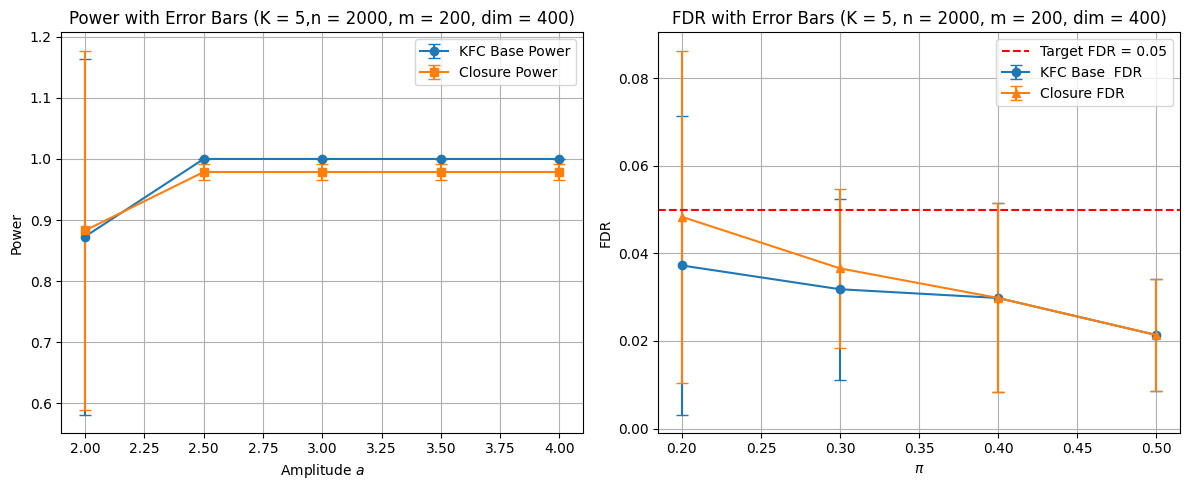

In [558]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
outliers = settings['props_outliers']
amps = settings['amps']

axes[0].errorbar(amps, power_base, yerr=err_power_base, fmt='-o', capsize=4, label='KFC Base Power')
#axes[0].errorbar(amps, power_boost, yerr=err_power_boost, fmt='-^', capsize=4, label='CC Boosted Power')
axes[0].errorbar(amps, power_closure, yerr=err_power_closure, fmt='-s', capsize=4, label='Closure Power')
axes[0].set_xlabel(r'Amplitude $a$')
axes[0].set_ylabel('Power')
axes[0].set_title(f'Power with Error Bars (K = {K_blocks},n = {n}, m = {m}, dim = {dimension})')
axes[0].legend()
axes[0].grid(True)

# Plot FDR with error bars
axes[1].errorbar(outliers, FDR_base, yerr=err_FDR_base, capsize=4, fmt='-o', label='KFC Base  FDR')
#axes[1].errorbar(outliers, FDR_boost, yerr=err_FDR_boost, fmt='-s',capsize=4, label='CC Boosted FDR')
axes[1].errorbar(outliers, FDR_closure, yerr=err_FDR_closure,  fmt='-^',capsize=4, label='Closure FDR')
axes[1].axhline(y=alpha_fdr, color='red', linestyle='--', label=f'Target FDR = {alpha_fdr}')
axes[1].set_xlabel(r'$\pi$')
axes[1].set_ylabel('FDR')
axes[1].set_title(f'FDR with Error Bars (K = {K_blocks}, n = {n}, m = {m}, dim = {dimension})')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

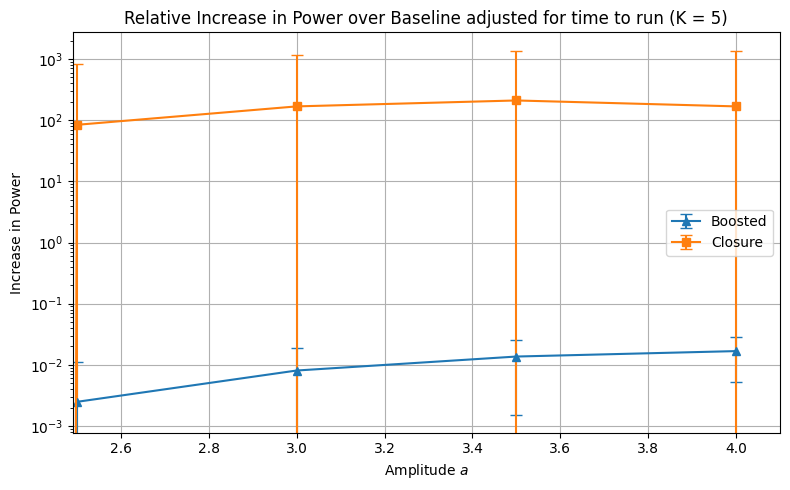

In [456]:
FDR_base        = np.array(FDR_base)
err_FDR_base    = np.array(err_FDR_base)
FDR_boost       = np.array(FDR_boost)
err_FDR_boost   = np.array(err_FDR_boost)
FDR_closure     = np.array(FDR_closure)
err_FDR_closure = np.array(err_FDR_closure)

power_base        = np.array(power_base)
err_power_base    = np.array(err_power_base)
power_boost       = np.array(power_boost)
err_power_boost   = np.array(err_power_boost)
power_closure     = np.array(power_closure)
err_power_closure = np.array(err_power_closure)

time_base = np.mean(times['Base'])
time_closure = np.mean(times['Closure'])
time_boost = np.mean(times['Boost'])

diff_boost = (power_boost - power_base)/time_boost
err_diff_boost = np.sqrt(err_power_boost**2 + err_power_base**2)/time_boost

diff_closure = (power_closure - power_base)/time_closure
err_diff_closure = np.sqrt(err_power_closure**2 + err_power_base**2)/time_closure

# Plot the increase in power relative to baseline
fig, ax = plt.subplots(figsize=(8, 5))

ax.errorbar(amps, diff_boost, yerr=err_diff_boost, fmt='-^', capsize=4, label='Boosted')
ax.errorbar(amps, diff_closure, yerr=err_diff_closure, fmt='-s', capsize=4, label='Closure')

ax.axhline(0, color='gray', linestyle='--', linewidth=1)
ax.set_xlabel(r'Amplitude $a$')
ax.set_ylabel('Increase in Power')

ax.set_yscale('log')
ax.set_xlim(left=2.49)

ax.set_title(f'Relative Increase in Power over Baseline adjusted for time to run (K = {K_blocks})')
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.show()

In [430]:
times

{'Base': [0.006207500002346933,
  0.0028912499838043004,
  0.002921582985436544,
  0.0028951249842066318,
  0.002939083002274856,
  0.0029353330028243363,
  0.0029364580113906413,
  0.002912291995016858,
  0.002905417000874877,
  0.002882750006392598,
  0.0028938330069649965,
  0.002990624983794987,
  0.0029292500112205744,
  0.002933790994575247,
  0.0029081659740768373,
  0.002914542012149468,
  0.0028752080106642097,
  0.002903874992625788,
  0.0029287500074133277,
  0.0029159580008126795,
  0.002907665999373421,
  0.00467654102249071,
  0.003049875027500093,
  0.0029370829870458692,
  0.002937375014880672,
  0.002899707993492484,
  0.0029266669880598783,
  0.0029193749942351133,
  0.002914249984314665,
  0.0028830000082962215,
  0.002899332990637049,
  0.0029155829979572445,
  0.0028845420165453106,
  0.002940042002592236,
  0.002890208997996524,
  0.002883707988075912,
  0.0029149999900255352,
  0.0017053339979611337,
  0.0016778749995864928,
  0.0016666660085320473,
  0.002045500

## Leftovers

In [375]:
def compute_cebh_discovery_set(E, alpha, mode='simple'):
    K = len(E)
    R_ebh = eBH(E, alpha)
    ebh_k = len(R_ebh)

    sorted_idx = np.argsort(E)[::-1] # sorted largest to smallest
    E_sorted = E[sorted_idx]

    E_prefix_sum = np.cumsum(E_sorted)
    E_suffix_sum = np.cumsum(E_sorted[::-1])


    res_dict = {}
    def get_r_of_k(r, k):
        if (r, k) not in res_dict:
            res_dict[(r, k)] = np.sum(E_sorted[(k - r):k])
        return res_dict[(r, k)]

    def get_evalue_fdp(k, r, m):
        """k is number of discoveries, r is number of false discoveries, m is number of nulls"""
        rejected_sum = get_r_of_k(r, k)
        nonreject_sum = E_suffix_sum[m - r - 1] if m > r else 0
        evalue = (rejected_sum + nonreject_sum) / m
        fdp = r / k
        return evalue, fdp
    def check_e_safety(k, r, m):
        evalue, fdp = get_evalue_fdp(k, r, m)
        return fdp <= alpha * evalue


    for k in range(K, ebh_k, -1):
        valid = True
        for r in range(1, k + 1): # of false discoveries
            for m in range(r, r + K + 1 - k): # total null count
                if not check_e_safety(k, r, m):
                    valid = False
                    break
            if not valid:
                break
        if valid:
            return set(sorted_idx[:k])
    return np.array(list(R_ebh))